# Comparación de los métodos de optimización

La guía (§3.4) pide comparar los cuatro métodos de búsqueda de hiperparámetros por la métrica del
bucle externo, el tiempo total y por evaluación, el número de evaluaciones y las curvas *anytime*,
y aportar evidencia cuantitativa de si la optimización bayesiana y la genética rinden más por
unidad de presupuesto. Esta página responde con los registros de la tabla maestra: cada corrida
guarda, para cada pliegue externo, la traza del mejor puntaje interno tras cada evaluación, el
historial de Optuna y, en el genético, la diversidad de la población por generación.

**Diseño de la comparación.** Dentro de cada modelo los cuatro métodos reciben el mismo presupuesto:
tantas configuraciones como tiene la rejilla de Grid Search de ese modelo (entre 30 y 48). Cada
configuración se evalúa con la misma validación interna de 3 pliegues dentro de cada uno de los 5
pliegues externos, de modo que las diferencias se deben solo a *qué* configuraciones elige cada
método y en qué orden. Un **bloque** es una pareja modelo × balanceo: los cuatro métodos se comparan
dentro del bloque y los bloques hacen de repeticiones. El análisis usa las 140 corridas de la guía,
que se ejecutaron en serie y con el equipo dedicado; las 20 del modelo nuevo siguen el mismo diseño,
pero compartieron el equipo con otros trabajos y sus tiempos no son comparables.

In [1]:
import sys
import warnings
from pathlib import Path

RAIZ = Path.cwd().parent
sys.path.insert(0, str(RAIZ))
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from src import analisis, graficos
from src import estadistica as est
from src.formato import dec, ent, enumerar, p_valor, pct

graficos.estilo()
pd.set_option('display.float_format', lambda v: f'{v:,.4f}')

tabla = analisis.cargar_tabla()
tabla = tabla[tabla['modelo'] != 'ebm']          # las 140 corridas de la guía
ok = tabla[tabla['estado'] == 'ok']
print(f'corridas de la guía: {len(tabla)} · entrenadas: {len(ok)} · '
      f'no aplican: {(tabla["estado"] == "no_aplica").sum()}')
print(ok.groupby(['tarea', 'optimizador']).size().unstack())

corridas de la guía: 140 · entrenadas: 136 · no aplican: 4
optimizador    bayesiana  genetica  grid  random
tarea                                           
clasificacion         27        27    27      27
regresion              7         7     7       7


## Resumen por método

Para cada tarea, el rango medio ordena los cuatro métodos dentro de cada bloque por la métrica del
bucle externo (1 = mejor; los empates reparten el rango) y las victorias cuentan en cuántos bloques
fue el mejor. El tiempo por evaluación es el tiempo de búsqueda entre el número de configuraciones
evaluadas, y el optimismo es la diferencia entre el mejor puntaje de la validación interna y el del
bucle externo.

In [2]:
resumen = analisis.resumen_optimizadores(tabla)
resumen

corridas  rango_medio  victorias  metrica_media  \
tarea         optimizador                                                    
clasificacion grid               27       2.2222         12         0.7759   
              random             27       3.2222          4         0.7740   
              bayesiana          27       2.6296          2         0.7757   
              genetica           27       1.9259         15         0.7760   
regresion     grid                7       2.7143          2         0.0609   
              random              7       2.7143          0         0.0609   
              bayesiana           7       2.1429          2         0.0609   
              genetica            7       2.4286          3         0.0609   

                           evaluaciones  s_por_evaluacion  min_por_corrida  \
tarea         optimizador                                                    
clasificacion grid             170.3704            2.6095           9.6200   
              random           170.3704            2.4555           9.0566   
              bayesiana        170.3704            4.4804          16.0614   
              genetica         170.3704            4.2678          15.3162   
regresion     grid             170.0000            2.4319           8.3754   
              random           170.0000            2.0550           7.1805   
              bayesiana        170.0000            2.9382          10.5272   
              genetica         170.0000            3.3694          11.6464   

                           horas_totales  optimismo  
tarea         optimizador                            
clasificacion grid                4.3290    -0.0013  
              random              4.0755    -0.0009  
              bayesiana           7.2276    -0.0010  
              genetica            6.8923    -0.0012  
regresion     grid                0.9771    -0.0001  
              random              0.8377    -0.0001  
              bayesiana           1.2282    -0.0001  
              genetica            1.3587    -0.0001

In [3]:
def fila(tarea, opt, col):
    return resumen.loc[(tarea, opt), col]

ratio_t = {t: (fila(t, 'bayesiana', 's_por_evaluacion') + fila(t, 'genetica', 's_por_evaluacion'))
           / (fila(t, 'grid', 's_por_evaluacion') + fila(t, 'random', 's_por_evaluacion'))
           for t in ('clasificacion', 'regresion')}
horas = resumen['horas_totales'].sum()
display(Markdown(f"""
Las {ent(len(ok))} corridas entrenadas consumieron {dec(horas, 1)} horas de cómputo. Con el mismo
número de evaluaciones, la bayesiana y la genética tardaron **{dec(ratio_t['clasificacion'], 1)} veces
más por evaluación** que Grid y Random en clasificación y {dec(ratio_t['regresion'], 1)} veces más en
regresión. La causa no es el coste del método (proponer un punto con TPE o generar una población
cuesta milisegundos) sino el paralelismo: Grid y Random conocen de antemano todas sus
configuraciones y `scikit-learn` reparte configuraciones × pliegues entre los 6 núcleos, mientras
que la bayesiana y la genética necesitan el resultado de una evaluación para proponer la siguiente
(o la generación siguiente), así que solo paralelizan los 3 pliegues internos de cada evaluación.
"""))


Las 136 corridas entrenadas consumieron 26,9 horas de cómputo. Con el mismo
número de evaluaciones, la bayesiana y la genética tardaron **1,7 veces
más por evaluación** que Grid y Random en clasificación y 1,4 veces más en
regresión. La causa no es el coste del método (proponer un punto con TPE o generar una población
cuesta milisegundos) sino el paralelismo: Grid y Random conocen de antemano todas sus
configuraciones y `scikit-learn` reparte configuraciones × pliegues entre los 6 núcleos, mientras
que la bayesiana y la genética necesitan el resultado de una evaluación para proponer la siguiente
(o la generación siguiente), así que solo paralelizan los 3 pliegues internos de cada evaluación.


## ¿Encuentran configuraciones distintas? Prueba de Friedman sobre la métrica externa

Si los métodos fueran equivalentes, su rango dentro de cada bloque sería aleatorio. La prueba de
Friedman contrasta esa hipótesis con los rangos de los bloques completos, y el diagrama de
diferencia crítica de Nemenyi muestra qué parejas de métodos se distinguen (las unidas por una barra
no difieren al 5 %).

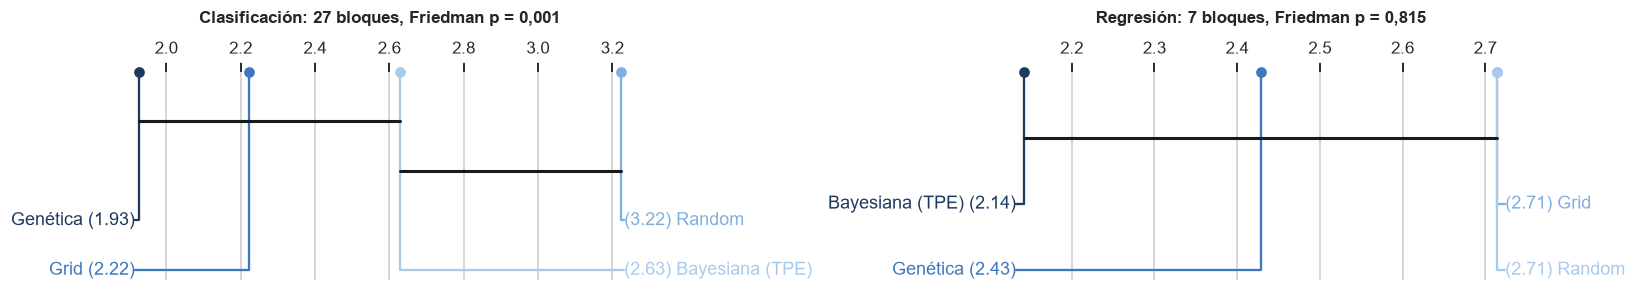

,bloques,chi2,p,F Iman-Davenport,p Iman-Davenport,diferencia crítica
clasificacion,27.0000,15.6591,0.0013,6.2310,0.0008,0.9027
regresion,7.0000,0.9429,0.8151,0.2821,0.8377,1.7728


In [4]:
friedman_metrica = {t: est.friedman(analisis.matriz_optimizadores(tabla, t)) for t in ('clasificacion', 'regresion')}
fig, ax = plt.subplots(1, 2, figsize=(15, 2.8))
for a, (t, r) in zip(ax, friedman_metrica.items()):
    graficos.diagrama_cd(r, ax=a, etiquetas=graficos.NOMBRE_OPTIMIZADOR,
                         titulo=f'{graficos.NOMBRE_TAREA[t]}: {r["n_bloques"]} bloques, Friedman {p_valor(r["p"], grafico=True)}')
plt.tight_layout()
plt.show()
pd.DataFrame({t: {'bloques': r['n_bloques'], 'chi2': r['chi2'], 'p': r['p'],
                  'F Iman-Davenport': r['F'], 'p Iman-Davenport': r['p_iman_davenport'],
                  'diferencia crítica': r['dc']} for t, r in friedman_metrica.items()}).T

In [5]:
dif_grid = analisis.diferencias_con_grid(tabla)
dif_grid

bloques   media  minimo  maximo  supera_a_grid  \
tarea         optimizador                                                   
clasificacion random            27 -0.0019 -0.0168  0.0019         0.2593   
              bayesiana         27 -0.0002 -0.0028  0.0008         0.4074   
              genetica          27  0.0001 -0.0020  0.0023         0.4444   
regresion     random             7  0.0000 -0.0001  0.0003         0.4286   
              bayesiana          7  0.0000 -0.0000  0.0003         0.7143   
              genetica           7  0.0000 -0.0002  0.0004         0.5714   

                           p_wilcoxon  
tarea         optimizador              
clasificacion random           0.0039  
              bayesiana        0.1864  
              genetica         0.4140  
regresion     random           1.0000  
              bayesiana        0.6875  
              genetica         0.9375

In [6]:
fc, fr = friedman_metrica['clasificacion'], friedman_metrica['regresion']
rc = fc['rangos_medios']
d_random = dif_grid.loc[('clasificacion', 'random')]
display(Markdown(f"""
En **clasificación** los métodos no son equivalentes (Friedman {p_valor(fc['p'])}, Iman-Davenport
{p_valor(fc['p_iman_davenport'])}, {fc['n_bloques']} bloques). El orden por rango medio es
{enumerar(f"{graficos.NOMBRE_CORTO_OPTIMIZADOR[o]} ({dec(v, 2)})" for o, v in rc.items())}. La diferencia que
sostiene la prueba es la de **Random**, que queda por debajo de Grid en {pct(1 - d_random['supera_a_grid'], 0)}
de los bloques, con una pérdida media de {dec(-d_random['media'], 4)} de AUC y hasta {dec(-d_random['minimo'], 4)}
en el peor bloque (Wilcoxon {p_valor(d_random['p_wilcoxon'])}). La bayesiana y la genética terminan
en el mismo nivel que Grid: sus diferencias medias son de {dec(dif_grid.loc[('clasificacion', 'bayesiana'), 'media'], 5, True)}
y {dec(dif_grid.loc[('clasificacion', 'genetica'), 'media'], 5, True)} de AUC, sin significación.

En **regresión** no hay diferencias (Friedman {p_valor(fr['p'])}, {fr['n_bloques']} bloques): con
uno a tres hiperparámetros por modelo, cualquier método que recorra el espacio con 30 puntos llega
al mismo óptimo.

La métrica final, por tanto, no separa a la bayesiana y la genética de Grid. Lo que sí las separa es
**cuánto presupuesto necesitan** para llegar a ese nivel, que es lo que miden las curvas *anytime*.
"""))


En **clasificación** los métodos no son equivalentes (Friedman p = 0,001, Iman-Davenport
p < 0,001, 27 bloques). El orden por rango medio es
genética (1,93), Grid (2,22), bayesiana (2,63) y Random (3,22). La diferencia que
sostiene la prueba es la de **Random**, que queda por debajo de Grid en 74 %
de los bloques, con una pérdida media de 0,0019 de AUC y hasta 0,0168
en el peor bloque (Wilcoxon p = 0,004). La bayesiana y la genética terminan
en el mismo nivel que Grid: sus diferencias medias son de −0,00022
y +0,00006 de AUC, sin significación.

En **regresión** no hay diferencias (Friedman p = 0,815, 7 bloques): con
uno a tres hiperparámetros por modelo, cualquier método que recorra el espacio con 30 puntos llega
al mismo óptimo.

La métrica final, por tanto, no separa a la bayesiana y la genética de Grid. Lo que sí las separa es
**cuánto presupuesto necesitan** para llegar a ese nivel, que es lo que miden las curvas *anytime*.


## Rendimiento por unidad de presupuesto: curvas *anytime*

Para cada bloque y cada pliegue externo se toma como referencia el mejor puntaje interno que
alcanzó cualquiera de los cuatro métodos y como punto de partida el peor primer puntaje. El
**arrepentimiento normalizado** tras *t* evaluaciones es la fracción de esa brecha que el método
todavía no ha cerrado: vale 1 al principio y 0 cuando el método ya encontró lo mejor que se
encontró. Así se pueden promediar modelos con métricas en escalas distintas. El área bajo la curva
resume la eficiencia en una cifra (menor es mejor) y se contrasta con Friedman sobre las
búsquedas (bloque × pliegue).

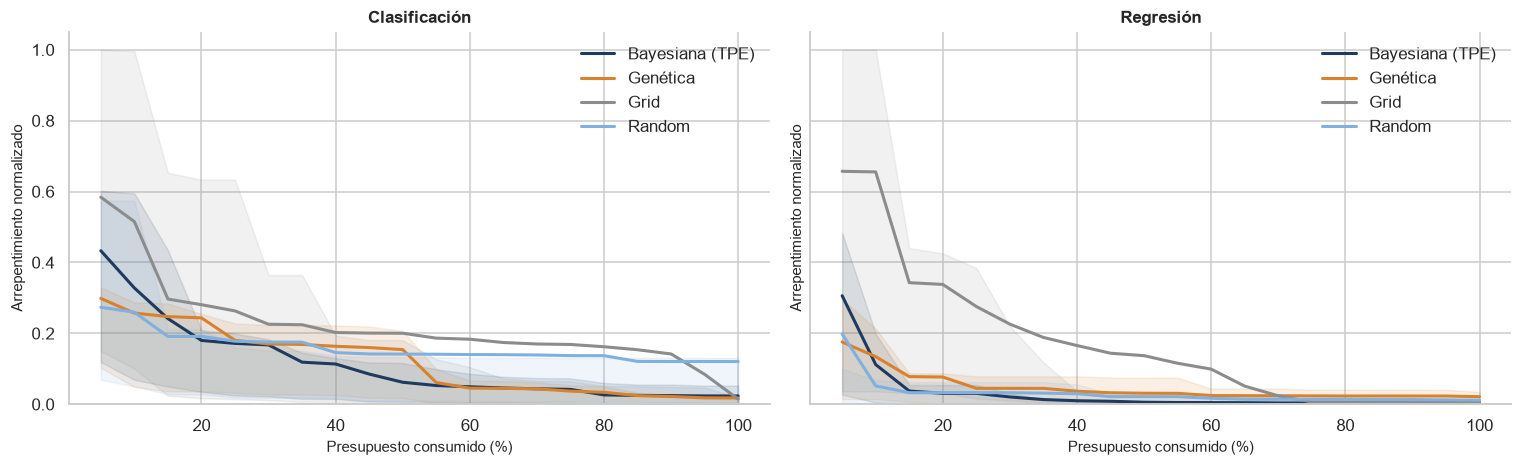

In [7]:
anytime = {t: analisis.curvas_anytime(tabla, t) for t in ('clasificacion', 'regresion')}
fig, ax = plt.subplots(1, 2, figsize=(14, 4.4), sharey=True)
for a, (t, (curvas, _)) in zip(ax, anytime.items()):
    graficos.curvas_anytime(curvas, ax=a, titulo=graficos.NOMBRE_TAREA[t])
plt.tight_layout()
plt.show()

In [8]:
filas = []
friedman_area = {}
for t, (_, por_busqueda) in anytime.items():
    m = por_busqueda.pivot_table(index=['modelo', 'balanceo', 'pliegue'], columns='optimizador', values='area')
    friedman_area[t] = est.friedman(m[analisis.OPTIMIZADORES], mayor_es_mejor=False)
    g = por_busqueda.groupby('optimizador')
    resumen_area = pd.DataFrame({
        'área media': g['area'].mean(), 'arrepentimiento final': g['final'].mean(),
        'evaluaciones hasta el 95 %': g['evals_al_95'].mean(),
        'búsquedas que llegan al 95 %': g['evals_al_95'].apply(lambda s: s.notna().mean()),
        'rango medio del área': friedman_area[t]['rangos_medios']})
    filas.append(resumen_area.reindex(analisis.OPTIMIZADORES).assign(tarea=t).set_index('tarea', append=True)
                 .reorder_levels([1, 0]))
eficiencia = pd.concat(filas)
eficiencia

área media  arrepentimiento final  \
tarea         optimizador                                      
clasificacion grid             0.2342                 0.0146   
              random           0.1707                 0.1205   
              bayesiana        0.1226                 0.0234   
              genetica         0.1365                 0.0176   
regresion     grid             0.1811                 0.0065   
              random           0.0409                 0.0117   
              bayesiana        0.0377                 0.0029   
              genetica         0.0575                 0.0214   

                           evaluaciones hasta el 95 %  \
tarea         optimizador                               
clasificacion grid                            14.2195   
              random                           7.1912   
              bayesiana                       10.2900   
              genetica                        13.0690   
regresion     grid                             9.9143   
              random                           7.4062   
              bayesiana                        5.4571   
              genetica                         7.4000   

                           búsquedas que llegan al 95 %  rango medio del área  
tarea         optimizador                                                      
clasificacion grid                               0.9111                2.9407  
              random                             0.5037                2.4481  
              bayesiana                          0.7407                2.0111  
              genetica                           0.8593                2.6000  
regresion     grid                               1.0000                3.5714  
              random                             0.9143                2.2000  
              bayesiana                          1.0000                1.9429  
              genetica                           0.8571                2.2857

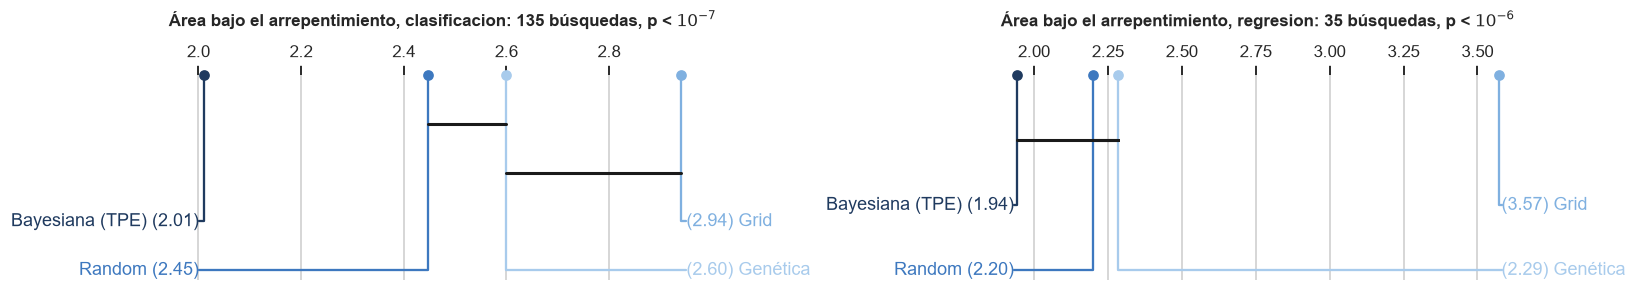

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(15, 2.8))
for a, (t, r) in zip(ax, friedman_area.items()):
    graficos.diagrama_cd(r, ax=a, etiquetas=graficos.NOMBRE_OPTIMIZADOR,
                         titulo=f'Área bajo el arrepentimiento, {t}: {r["n_bloques"]} búsquedas, {p_valor(r["p"], grafico=True)}')
plt.tight_layout()
plt.show()

In [10]:
fa_c, fa_r = friedman_area['clasificacion'], friedman_area['regresion']
pn_c = fa_c['p_nemenyi']
e_c = eficiencia.loc['clasificacion']
e_r = eficiencia.loc['regresion']
display(Markdown(f"""
Aquí sí hay un ganador claro. La **optimización bayesiana** es el método más eficiente por unidad de
presupuesto en las dos tareas: tiene el menor rango medio del área bajo el arrepentimiento
({dec(fa_c['rangos_medios']['bayesiana'], 2)} en clasificación y {dec(fa_r['rangos_medios']['bayesiana'], 2)} en
regresión; Friedman {p_valor(fa_c['p'])} y {p_valor(fa_r['p'])}). En clasificación cierra el 95 % de la
brecha en {dec(e_c.loc['bayesiana', 'evaluaciones hasta el 95 %'], 1)} evaluaciones de media, frente a
{dec(e_c.loc['grid', 'evaluaciones hasta el 95 %'], 1)} de Grid, y Nemenyi la separa de Grid
({p_valor(pn_c.loc['bayesiana', 'grid'])}), de Random ({p_valor(pn_c.loc['bayesiana', 'random'])}) y de la
genética ({p_valor(pn_c.loc['bayesiana', 'genetica'])}).

La **genética** es más eficiente que Grid en regresión (Nemenyi {p_valor(fa_r['p_nemenyi'].loc['genetica', 'grid'])})
pero no en clasificación ({p_valor(pn_c.loc['genetica', 'grid'])}): su población inicial es aleatoria y
necesita varias generaciones para concentrarse, y con presupuestos de 30 a 48 evaluaciones solo
alcanza 5 a 7 generaciones. A cambio, es la que termina con mejor rango en la métrica externa de
clasificación: explora más y, cuando el presupuesto se agota, sus mejores configuraciones
generalizan igual o mejor que las de Grid.

**Random** arranca rápido (las primeras evaluaciones ya cubren el espacio entero), pero solo
{pct(e_c.loc['random', 'búsquedas que llegan al 95 %'], 0)} de sus búsquedas de clasificación llegan a cerrar el 95 % de la
brecha y termina con el mayor arrepentimiento final ({dec(e_c.loc['random', 'arrepentimiento final'], 3)}).
**Grid** es el menos eficiente: recorre la rejilla en un orden fijo que no aprende de lo evaluado.
"""))


Aquí sí hay un ganador claro. La **optimización bayesiana** es el método más eficiente por unidad de
presupuesto en las dos tareas: tiene el menor rango medio del área bajo el arrepentimiento
(2,01 en clasificación y 1,94 en
regresión; Friedman p < 10⁻⁷ y p < 10⁻⁶). En clasificación cierra el 95 % de la
brecha en 10,3 evaluaciones de media, frente a
14,2 de Grid, y Nemenyi la separa de Grid
(p < 10⁻⁷), de Random (p = 0,028) y de la
genética (p = 0,001).

La **genética** es más eficiente que Grid en regresión (Nemenyi p < 0,001)
pero no en clasificación (p = 0,132): su población inicial es aleatoria y
necesita varias generaciones para concentrarse, y con presupuestos de 30 a 48 evaluaciones solo
alcanza 5 a 7 generaciones. A cambio, es la que termina con mejor rango en la métrica externa de
clasificación: explora más y, cuando el presupuesto se agota, sus mejores configuraciones
generalizan igual o mejor que las de Grid.

**Random** arranca rápido (las primeras evaluaciones ya cubren el espacio entero), pero solo
50 % de sus búsquedas de clasificación llegan a cerrar el 95 % de la
brecha y termina con el mayor arrepentimiento final (0,120).
**Grid** es el menos eficiente: recorre la rejilla en un orden fijo que no aprende de lo evaluado.


## Dentro de la optimización bayesiana: arranque aleatorio y explotación del modelo

TPE empieza con un tercio del presupuesto (como máximo 10 ensayos) de puntos aleatorios para
estimar sus dos densidades, ℓ(x) de las configuraciones buenas y g(x) de las malas, y a partir de
ahí propone el punto que maximiza ℓ(x)/g(x), que equivale a maximizar la mejora esperada. Si el
modelo aprende algo útil, los ensayos posteriores al arranque deben puntuar mejor que los del
arranque.

In [11]:
filas = []
for _, f in ok[ok['optimizador'] == 'bayesiana'].iterrows():
    for d in f['detalles']:
        h = np.asarray(d['historial'], dtype=float)
        k = d['n_startup_trials']
        h = h[np.isfinite(h)]
        if len(h) <= k:
            continue
        corte = np.quantile(h, 0.75)
        filas.append({'tarea': f['tarea'], 'modelo': f['modelo'],
                      'arranque en el cuartil superior': np.mean(h[:k] >= corte),
                      'guiados en el cuartil superior': np.mean(h[k:] >= corte),
                      'mediana arranque': np.median(h[:k]), 'mediana guiados': np.median(h[k:])})
tpe = pd.DataFrame(filas)
tpe_resumen = tpe.groupby('tarea')[['arranque en el cuartil superior', 'guiados en el cuartil superior']].mean()
tpe_resumen

,arranque en el cuartil superior,guiados en el cuartil superior
tarea,,
clasificacion,0.0533,0.3486
regresion,0.1000,0.3274


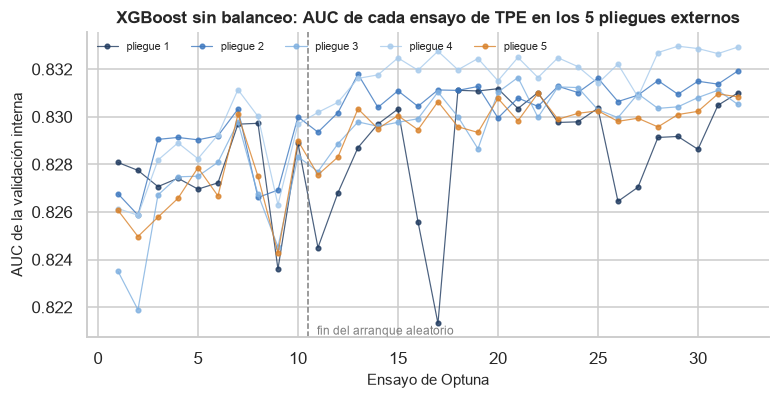

In [12]:
fig, ax = plt.subplots(figsize=(8, 3.6))
ejemplo = ok[(ok['optimizador'] == 'bayesiana') & (ok['modelo'] == 'xgboost') & (ok['tarea'] == 'clasificacion')
             & (ok['balanceo'] == 'ninguno')].iloc[0]
for i, d in enumerate(ejemplo['detalles']):
    h = np.asarray(d['historial'], dtype=float)
    ax.plot(np.arange(1, len(h) + 1), h, marker='o', ms=3, lw=0.8, alpha=0.8, label=f'pliegue {i + 1}')
ax.axvline(ejemplo['detalles'][0]['n_startup_trials'] + 0.5, color='grey', ls='--', lw=1)
ax.text(ejemplo['detalles'][0]['n_startup_trials'] + 0.8, ax.get_ylim()[0], ' fin del arranque aleatorio',
        va='bottom', fontsize=8, color='grey')
ax.set_xlabel('Ensayo de Optuna')
ax.set_ylabel('AUC de la validación interna')
ax.set_title('XGBoost sin balanceo: AUC de cada ensayo de TPE en los 5 pliegues externos')
ax.legend(frameon=False, fontsize=7, ncol=5)
plt.show()

In [13]:
tc = tpe_resumen.loc['clasificacion']
display(Markdown(f"""
En clasificación, {pct(tc['guiados en el cuartil superior'], 0)} de los ensayos que propone TPE después del
arranque caen en el cuartil superior de su propio estudio, frente a {pct(tc['arranque en el cuartil superior'], 0)}
de los ensayos aleatorios del arranque. Si el modelo no aprendiera nada, las dos cifras serían
parecidas: el sustituto concentra la búsqueda en la región buena, que es la fuente de la ventaja
*anytime* de la sección anterior.
"""))


En clasificación, 35 % de los ensayos que propone TPE después del
arranque caen en el cuartil superior de su propio estudio, frente a 5 %
de los ensayos aleatorios del arranque. Si el modelo no aprendiera nada, las dos cifras serían
parecidas: el sustituto concentra la búsqueda en la región buena, que es la fuente de la ventaja
*anytime* de la sección anterior.


## Dentro del algoritmo genético: diversidad y convergencia

El genético usa selección por torneo de tamaño 3, cruce uniforme (probabilidad de intercambio 0,5
por gen, aplicado con probabilidad 0,6), mutación gaussiana con desviación 0,15 sobre genes
codificados en [0, 1] (probabilidad 1/n por gen, aplicada con probabilidad 0,3) y elitismo: el
mejor individuo se reinserta en cada generación. La población y el número de generaciones se
derivan del presupuesto (con 30 evaluaciones, 7 individuos y 6 generaciones), y una caché de
genomas evita gastar presupuesto en configuraciones repetidas. La guía pide registrar la
diversidad por generación: aquí es la desviación típica de cada gen (codificado en [0, 1]) a través
de la población, promediada sobre los genes; vale 0 cuando todos los individuos son idénticos.

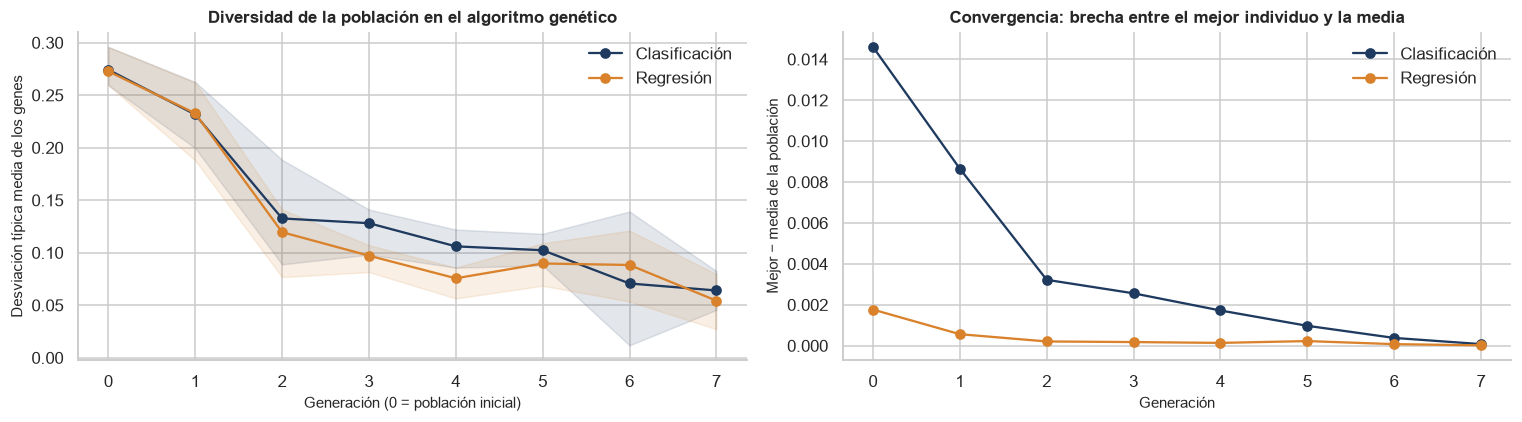


La diversidad cae de 0,274 en la población inicial a 0,078 en la última generación:
la población converge hacia la región de las mejores configuraciones sin colapsar del todo, porque la
mutación sigue introduciendo variación. La brecha entre el mejor individuo y la media se cierra al
mismo ritmo, señal de que el elitismo y el torneo están arrastrando a toda la población, no solo
conservando al mejor.


In [14]:
div = analisis.diversidad_genetica(tabla)
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
graficos.diversidad_genetica(div, ax=ax[0])
conv = div.groupby(['tarea', 'generacion'])[['mejor', 'media']].mean()
for t, color in (('clasificacion', graficos.AZUL), ('regresion', '#d9822b')):
    g = div[div['tarea'] == t].copy()
    g['brecha'] = g['mejor'] - g['media']
    b = g.groupby('generacion')['brecha'].mean()
    ax[1].plot(b.index, b.values, marker='o', color=color, label=graficos.NOMBRE_TAREA[t])
ax[1].set_xlabel('Generación')
ax[1].set_ylabel('Mejor − media de la población')
ax[1].set_title('Convergencia: brecha entre el mejor individuo y la media')
ax[1].legend(frameon=False)
plt.tight_layout()
plt.show()
d_ini = div[div['generacion'] == 0]['diversidad'].mean()
d_fin = div.groupby(['tarea', 'modelo', 'balanceo', 'pliegue'])['diversidad'].last().mean()
display(Markdown(f"""
La diversidad cae de {dec(d_ini, 3)} en la población inicial a {dec(d_fin, 3)} en la última generación:
la población converge hacia la región de las mejores configuraciones sin colapsar del todo, porque la
mutación sigue introduciendo variación. La brecha entre el mejor individuo y la media se cierra al
mismo ritmo, señal de que el elitismo y el torneo están arrastrando a toda la población, no solo
conservando al mejor.
"""))

## Optimismo de selección

El mejor puntaje de la validación interna es una estimación sesgada al alza, porque es el máximo de
muchas evaluaciones ruidosas; por eso la guía obliga a reportar la métrica del bucle externo. La
diferencia entre ambos mide ese sesgo.

In [15]:
opt = ok.groupby(['tarea', 'optimizador'])['optimismo_seleccion'].agg(['mean', 'min', 'max']).reindex(
    analisis.OPTIMIZADORES, level='optimizador')
opt

mean     min     max
tarea         optimizador                        
clasificacion grid        -0.0013 -0.0084  0.0022
              random      -0.0009 -0.0084  0.0025
              bayesiana   -0.0010 -0.0084  0.0023
              genetica    -0.0012 -0.0084  0.0027
regresion     grid        -0.0001 -0.0003 -0.0000
              random      -0.0001 -0.0002 -0.0000
              bayesiana   -0.0001 -0.0002 -0.0000
              genetica    -0.0001 -0.0002 -0.0000

In [16]:
oc = ok[ok['tarea'] == 'clasificacion']['optimismo_seleccion']
media_opt = opt.loc['clasificacion', 'mean']
adaptativos_mas_optimistas = max(media_opt['bayesiana'], media_opt['genetica']) > media_opt['grid'] + 0.0005
n_train = int(ok['n_train'].iloc[0])
display(Markdown(f"""
El optimismo sale **{'negativo' if oc.mean() < 0 else 'positivo'}** en promedio (media {dec(oc.mean(), 4, True)} de AUC
en clasificación){': la validación interna *subestima* el desempeño externo' if oc.mean() < 0 else ''}. Hay dos
fuerzas opuestas. El máximo de 30 a 48 evaluaciones sesga al alza, pero cada modelo interno se
entrena con dos tercios del pliegue externo (unas {ent(n_train * 4 / 5 * 2 / 3)} filas) y el del bucle
externo con el pliegue completo (unas {ent(n_train * 4 / 5)}): con curvas de aprendizaje que todavía
suben, el efecto del tamaño {'domina' if oc.mean() < 0 else 'no alcanza a compensar el de la selección'}.
{'Los métodos adaptativos, que buscan el máximo con más insistencia, muestran más optimismo que Grid ('
 + dec(media_opt['bayesiana'], 4, True) + ' la bayesiana y ' + dec(media_opt['genetica'], 4, True) + ' la genética, frente a '
 + dec(media_opt['grid'], 4, True) + ').' if adaptativos_mas_optimistas else
 'Los métodos adaptativos, que buscan el máximo con más insistencia, no muestran más optimismo que Grid ('
 + dec(media_opt['bayesiana'], 4, True) + ' la bayesiana y ' + dec(media_opt['genetica'], 4, True) + ' la genética, frente a '
 + dec(media_opt['grid'], 4, True) + '): su mejor puntaje interno no está sobreajustado a los pliegues internos.'}
"""))


El optimismo sale **negativo** en promedio (media −0,0011 de AUC
en clasificación): la validación interna *subestima* el desempeño externo. Hay dos
fuerzas opuestas. El máximo de 30 a 48 evaluaciones sesga al alza, pero cada modelo interno se
entrena con dos tercios del pliegue externo (unas 20.788 filas) y el del bucle
externo con el pliegue completo (unas 31.182): con curvas de aprendizaje que todavía
suben, el efecto del tamaño domina.
Los métodos adaptativos, que buscan el máximo con más insistencia, no muestran más optimismo que Grid (−0,0010 la bayesiana y −0,0012 la genética, frente a −0,0013): su mejor puntaje interno no está sobreajustado a los pliegues internos.


## Conclusión

In [17]:
display(Markdown(f"""
- Con el mismo número de evaluaciones, **la optimización bayesiana es la que mejor aprovecha el
  presupuesto**: llega antes al nivel final en las dos tareas, con diferencias significativas frente
  a Grid y Random. Es la respuesta cuantitativa que pide la guía.
- **La métrica final apenas distingue a los métodos.** Bayesiana, genética y Grid terminan dentro
  de una fracción de milésima de AUC; solo Random queda por debajo de forma consistente. Con
  espacios de 1 a 7 hiperparámetros y 30 a 48 evaluaciones, el presupuesto alcanza para que los
  métodos sistemáticos encuentren la meseta del óptimo.
- **En tiempo de reloj la ventaja se invierte**: la bayesiana y la genética son secuenciales y
  tardaron {dec(ratio_t['clasificacion'], 1)} veces más por evaluación en este equipo de 6 núcleos. Con más
  núcleos, o con evaluaciones caras que ya usan todos los núcleos por sí mismas (Random Forest,
  la EBM), la ventaja por evaluación se convierte en ventaja de tiempo.
- La multi-fidelidad aplicada a Random Forest (100 árboles en la búsqueda y 300 en el modelo final)
  y a la EBM (2 y 8 bolsas) se valida en la sección de cómputo.
"""))


- Con el mismo número de evaluaciones, **la optimización bayesiana es la que mejor aprovecha el
  presupuesto**: llega antes al nivel final en las dos tareas, con diferencias significativas frente
  a Grid y Random. Es la respuesta cuantitativa que pide la guía.
- **La métrica final apenas distingue a los métodos.** Bayesiana, genética y Grid terminan dentro
  de una fracción de milésima de AUC; solo Random queda por debajo de forma consistente. Con
  espacios de 1 a 7 hiperparámetros y 30 a 48 evaluaciones, el presupuesto alcanza para que los
  métodos sistemáticos encuentren la meseta del óptimo.
- **En tiempo de reloj la ventaja se invierte**: la bayesiana y la genética son secuenciales y
  tardaron 1,7 veces más por evaluación en este equipo de 6 núcleos. Con más
  núcleos, o con evaluaciones caras que ya usan todos los núcleos por sí mismas (Random Forest,
  la EBM), la ventaja por evaluación se convierte en ventaja de tiempo.
- La multi-fidelidad aplicada a Random Forest (100 árboles en la búsqueda y 300 en el modelo final)
  y a la EBM (2 y 8 bolsas) se valida en la sección de cómputo.
